# Level 3: Numerical Methods

**Project:** HydroSense-Kenya  
**Level:** 3 of 6

---

### Objective

HydroSense relies on numerical computation to estimate irrigation requirements, predict soil moisture behaviour, and analyse environmental data.

In this part of the project, we implement and evaluate several fundamental numerical methods:

1. Root Finding
   - Bisection Method
   - Newton-Raphson Method
   - Secant Method

2. Numerical Integration
   - Trapezoidal Rule
   - Simpson's Rule

3. Solving Linear Systems
   - Gaussian Elimination

The methods are applied to realistic HydroSense scenarios rather than generic textbook examples.

---

### Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.numerical_methods import (
    bisection,
    newton_raphson,
    secant,
    trapezoidal,
    simpson,
    gaussian_elimination
)

plt.rcParams["figure.figsize"] = (8,4)

### Loading the data 

In [2]:
weather = pd.read_csv("../data/processed/weather_daily_cleaned.csv")
soil = pd.read_csv("../data/processed/soil_sensor_data_cleaned.csv")
params = pd.read_csv("../data/processed/crop_zone_parameters_cleaned.csv")

print(weather.shape)
print(soil.shape)
print(params.shape)

(28, 6)
(89, 7)
(3, 7)


## Part A: Root Finding

Many scientific problems involve finding the value of x that makes:

$$
f(x)=0
$$

In HydroSense this can represent:

- irrigation volume needed to reach target moisture
- equilibrium soil moisture
- water balance solutions

We compare three root-finding methods. 


---

Let's define a python function called `moisture_equation` which will be used as the overall equation example. The function computes and returns the value(s) of the example equation; 

$$
x^3 - 5x - 9
$$


In [3]:
def moisture_equation(x):
    return x**3 - 5*x - 9

### Visualising the Function

Before attempting to find a root, it is useful to inspect the behaviour of the function graphically.

A root occurs where the curve crosses the x-axis.

Visualisation allows us to:

- Verify that a root exists
- Estimate where the root lies
- Select reasonable starting values for iterative methods

This reduces the likelihood of convergence failures.

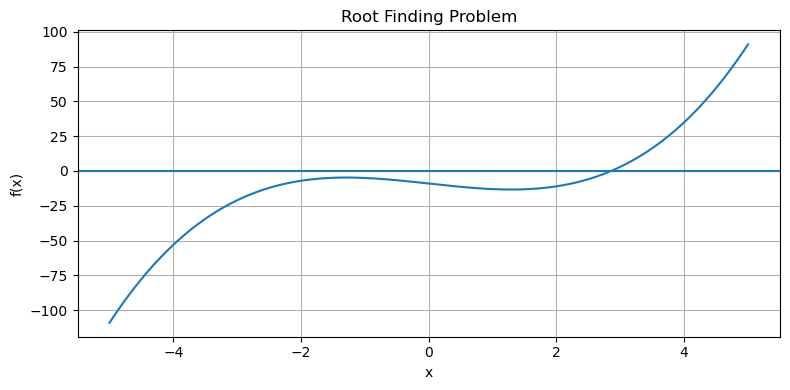

In [4]:
x = np.linspace(-5,5,500)

plt.plot(x, moisture_equation(x))
plt.axhline(0)

plt.title("Root Finding Problem")
plt.xlabel("x")
plt.ylabel("f(x)")

plt.grid()

plt.tight_layout()
plt.show()

### Bisection Method

The Bisection Method repeatedly halves an interval until the root is isolated.

Advantages:

- Guaranteed convergence
- Very stable

Disadvantages:

- Slower than other methods

---

#### implementation in code

we use the earlier defined `moisture_equation` and `bisection` function to find the results

##### Understanding the Output

The Bisection Method returns several pieces of information:

- Root → estimated solution
- Iterations → number of interval halvings performed
- Converged → whether the algorithm successfully met the stopping criterion

A smaller number of iterations generally indicates better efficiency.

In [5]:
result = bisection(moisture_equation, 2, 3)

# result

print("Root:", result["root"])
print("Iterations:", result["iterations"])
print("Error:", result["error"])
print("Converged:", result["converged"])

Root: 2.855196952819824
Iterations: 20
Error: 9.5367431640625e-07
Converged: True


### Newton-Raphson Method

Newton-Raphson uses the derivative to rapidly approach the root.

Advantages:

- Extremely fast

Disadvantages:

- Requires derivative information
- Can diverge if poorly initialized

---

Since this metnood is dependant on derivatives, we will first define a function that returns the derivative of the `moisture_equation` function. We will call it `moisture_derivative`. The equation of the function is; 

$$
3x^2 - 5
$$


In [6]:
def moisture_derivative(x):
    return 3*x**2 - 5

#### implementation in code

In [7]:
result_nr = newton_raphson(
    moisture_equation,
    moisture_derivative,
    x0=2.5
)

# result_nr

print("Root:", result_nr["root"])
print("Iterations:", result_nr["iterations"])
print("error:", result_nr["error"])
print("Converged:", result_nr["converged"])

Root: 2.855196539320705
Iterations: 5
error: 1.9397816686250735e-12
Converged: True


### Secant Method

The Secant Method avoids computing derivatives explicitly. Instead, it estimates the derivative using two nearby points. This often provides performance close to Newton-Raphson while avoiding derivative calculations. 
Such derivative-free approaches are useful when working with empirical agricultural models whose analytical derivatives are difficult to obtain.

Advantages:

- Faster than Bisection
- No derivative required

Disadvantages:

- Less stable

---

#### implementation in code

In [8]:
result_secant = secant(
    moisture_equation,
    2,
    3
)

# result_secant

print("Root:", result_secant["root"])
print("Iterations:", result_secant["iterations"])
print("error:", result_secant["error"])
print("Converged:", result_secant["converged"])

Root: 2.8551965393053247
Iterations: 5
error: 2.5797389602288945e-07
Converged: True


### Method Comparison

Although all three algorithms should converge to approximately the same root, their computational cost differs.

For HydroSense systems deployed on embedded hardware:

- Faster convergence means fewer computations.
- Fewer computations reduce power consumption.
- Reduced power consumption increases battery life.

This makes algorithm selection an important engineering decision.

In [9]:
comparison = pd.DataFrame({
    "Method":[
        "Bisection",
        "Newton-Raphson",
        "Secant"
    ],
    "Root":[
        result["root"],
        result_nr["root"],
        result_secant["root"]
    ],
    "Iterations":[
        result["iterations"],
        result_nr["iterations"],
        result_secant["iterations"]
    ]
})

comparison

,Method,Root,Iterations
0,Bisection,2.855197,20
1,Newton-Raphson,2.855197,5
2,Secant,2.855197,5


#### visualisation comparison of methods

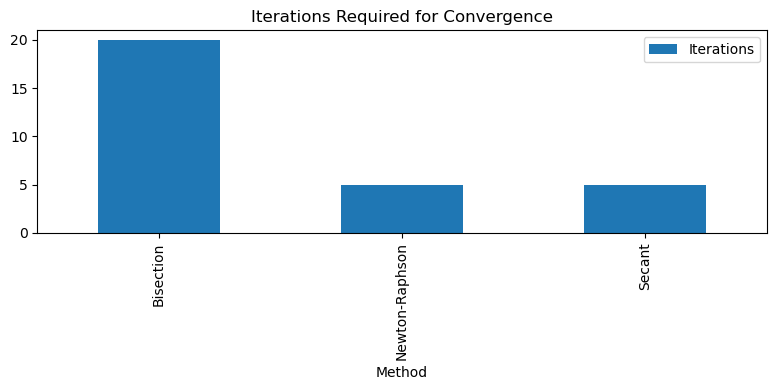

In [10]:
comparison.plot(
    x="Method",
    y="Iterations",
    kind="bar"
)

plt.title("Iterations Required for Convergence")
plt.tight_layout()
plt.show()

### Interpretation

All methods converge to the same root.

However:

- Newton-Raphson typically converges fastest.
- Secant is usually second.
- Bisection is slower but extremely reliable.

For embedded irrigation systems, computational efficiency is important because calculations may occur continuously. 

---

## Part B: Numerical Integration

Integration is required whenever HydroSense needs to estimate:

- total rainfall
- accumulated evapotranspiration
- cumulative irrigation

from discrete observations.

In [11]:
rainfall = weather["rainfall_mm"].values
days = np.arange(len(rainfall))

### Trapezoidal Rule

The Trapezoidal Rule approximates the area under a curve using trapeziums. The interval between consecutive measurements is treated as a straight line. The areas of all trapeziums are then summed to estimate the total area. Although simple, this method performs surprisingly well for many environmental datasets. 

In [12]:
trap_result = trapezoidal(
    days,
    rainfall
)

# trap_result

print("Estimated accumulated rainfall:")
print(trap_result)

Estimated accumulated rainfall:
245.78103448275857


### Simpson's Rule

Simpson's Rule improves accuracy by approximating the curve using quadratic polynomials rather than straight lines. Because environmental variables often vary smoothly, Simpson's Rule frequently provides more accurate estimates than the Trapezoidal Rule. This makes it particularly useful when estimating accumulated rainfall or evapotranspiration. 

In [13]:
simpson_result = simpson(
    days,
    rainfall
)

# simpson_result

print("Simpson Estimate:")
print(simpson_result)

Simpson Estimate:
271.5580459770115


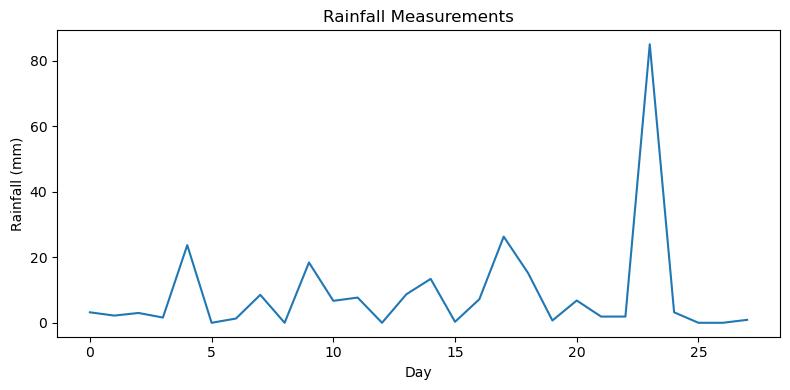

In [14]:
plt.plot(days, rainfall)

plt.title("Rainfall Measurements")
plt.xlabel("Day")
plt.ylabel("Rainfall (mm)")

plt.tight_layout()
plt.show()

In [15]:
integration_results = pd.DataFrame({
    "Method":[
        "Trapezoidal",
        "Simpson"
    ],
    "Result":[
        trap_result,
        simpson_result
    ]
})

integration_results

,Method,Result
0,Trapezoidal,245.781034
1,Simpson,271.558046


### Interpretation

Both methods estimate the area under the rainfall curve.

Simpson's Rule is generally more accurate because it approximates the curve using parabolic segments rather than straight lines.

---

## Part C: Gaussian Elimination

HydroSense may need to solve systems of equations involving:

- irrigation allocation
- reservoir balancing
- multi-zone water distribution

Gaussian Elimination transforms a matrix into an upper triangular form and solves the system efficiently. 

### Linear Systems in HydroSense

Many engineering problems can be represented as systems of simultaneous equations.

Examples include:

- Water allocation between zones
- Pump scheduling
- Reservoir balancing
- Resource optimization

These systems are commonly expressed in matrix form:

$$
Ax = b
$$

where:

- A represents system coefficients
- x contains the unknown variables
- b contains known quantities

Gaussian Elimination solves for the unknown vector x. 

#### Example System

For demonstration purposes, we construct a small 3 × 3 system. Although simplified, it illustrates the same mathematical process used in much larger optimization and allocation problems. The objective is to determine the values of the unknown variables that satisfy all equations simultaneously.

In [16]:
A = np.array([
    [3,2,-1],
    [2,-2,4],
    [-1,0.5,-1]
], dtype=float)

b = np.array([
    1,
    -2,
    0
], dtype=float)

In [17]:
import src.numerical_methods as nm

solution = nm.gaussian_elimination(A, b)

print("Solution:")
print(solution)

Solution:
[ 1. -2. -2.]


In [18]:
variables = pd.DataFrame({
    "Variable":["x","y","z"],
    "Value":solution
})

variables

,Variable,Value
0,x,1.0
1,y,-2.0
2,z,-2.0


### Interpretation

The solution vector satisfies:

$$
Ax=b
$$

Such systems appear frequently in optimization and resource allocation problems.

Gaussian Elimination provides an efficient deterministic solution.

## Conclusion

This notebook demonstrated several key numerical methods used throughout scientific computing.

Key observations:

- Root-finding methods can determine unknown system states.
- Numerical integration estimates cumulative environmental quantities.
- Gaussian Elimination solves systems of equations efficiently.
- Different methods vary in speed, accuracy, and robustness.

These techniques form the computational foundation for HydroSense simulation and optimization tasks that will be explored in subsequent levels.